# DATA WRANGLING

#  Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load  Dataset

In [2]:
df = pd.read_csv('accident_prediction_india.csv')

# Clean Column name

In [3]:
df.columns = df.columns.str.strip()

# Shape

In [4]:
print("1. SHAPE:", df.shape)

1. SHAPE: (3000, 22)


# Column names

In [5]:
print("2. COLUMN NAMES:")
print(df.columns.tolist())

2. COLUMN NAMES:
['State Name', 'City Name', 'Year', 'Month', 'Day of Week', 'Time of Day', 'Accident Severity', 'Number of Vehicles Involved', 'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities', 'Weather Conditions', 'Road Type', 'Road Condition', 'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)', 'Driver Age', 'Driver Gender', 'Driver License Status', 'Alcohol Involvement', 'Accident Location Details']


# Info

In [6]:
print("3. DATA TYPES & INFO:")
df.info()

3. DATA TYPES & INFO:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   State Name                   3000 non-null   str  
 1   City Name                    3000 non-null   str  
 2   Year                         3000 non-null   int64
 3   Month                        3000 non-null   str  
 4   Day of Week                  3000 non-null   str  
 5   Time of Day                  3000 non-null   str  
 6   Accident Severity            3000 non-null   str  
 7   Number of Vehicles Involved  3000 non-null   int64
 8   Vehicle Type Involved        3000 non-null   str  
 9   Number of Casualties         3000 non-null   int64
 10  Number of Fatalities         3000 non-null   int64
 11  Weather Conditions           3000 non-null   str  
 12  Road Type                    3000 non-null   str  
 13  Road Condition               3000 non

# First 5 rows

In [7]:
print("4. FIRST 5 ROWS:")
print(df.head())

4. FIRST 5 ROWS:
          State Name City Name  Year    Month Day of Week Time of Day  \
0  Jammu and Kashmir   Unknown  2021      May      Monday        1:46   
1      Uttar Pradesh   Lucknow  2018  January   Wednesday       21:30   
2       Chhattisgarh   Unknown  2023      May   Wednesday        5:37   
3      Uttar Pradesh   Lucknow  2020     June    Saturday        0:31   
4             Sikkim   Unknown  2021   August    Thursday       11:21   

  Accident Severity  Number of Vehicles Involved Vehicle Type Involved  \
0           Serious                            5                 Cycle   
1             Minor                            5                 Truck   
2             Minor                            5            Pedestrian   
3             Minor                            3                   Bus   
4             Minor                            5                 Cycle   

   Number of Casualties  ...         Road Type      Road Condition  \
0                     0  ... 

# Numerical Summary

In [8]:
print("5. NUMERICAL SUMMARY:")
print(df.describe())

5. NUMERICAL SUMMARY:
              Year  Number of Vehicles Involved  Number of Casualties  \
count  3000.000000                  3000.000000           3000.000000   
mean   2020.530000                     2.996000              5.066000   
std       1.683858                     1.428285              3.214097   
min    2018.000000                     1.000000              0.000000   
25%    2019.000000                     2.000000              2.000000   
50%    2021.000000                     3.000000              5.000000   
75%    2022.000000                     4.000000              8.000000   
max    2023.000000                     5.000000             10.000000   

       Number of Fatalities  Speed Limit (km/h)  Driver Age  
count           3000.000000         3000.000000  3000.00000  
mean               2.455333           74.940667    44.17700  
std                1.717650           26.765088    15.40286  
min                0.000000           30.000000    18.00000  
25%       

# Categorical Summary

In [9]:
print("6. Categorical Summary:")
print(df.describe(include='object'))

6. Categorical Summary:
       State Name City Name  Month Day of Week Time of Day Accident Severity  \
count        3000      3000   3000        3000        3000              3000   
unique         32        28     12           7        1263                 3   
top           Goa   Unknown  March   Wednesday        3:40             Minor   
freq          109      2138    266         468           7              1034   

       Vehicle Type Involved Weather Conditions      Road Type  \
count                   3000               3000           3000   
unique                     7                  5              4   
top                    Truck              Rainy  State Highway   
freq                     449                631            771   

            Road Condition Lighting Conditions Traffic Control Presence  \
count                 3000                3000                     2284   
unique                   4                   4                        3   
top     Under Const

/var/folders/1r/9r_t36z11gd_v0gzq523dzdw0000gp/T/ipykernel_33150/2817861005.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


# Unique Values 

In [10]:
print("7. UNIQUE VALUES:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

7. UNIQUE VALUES:
State Name: 32
City Name: 28
Year: 6
Month: 12
Day of Week: 7
Time of Day: 1263
Accident Severity: 3
Number of Vehicles Involved: 5
Vehicle Type Involved: 7
Number of Casualties: 11
Number of Fatalities: 6
Weather Conditions: 5
Road Type: 4
Road Condition: 4
Lighting Conditions: 4
Traffic Control Presence: 3
Speed Limit (km/h): 91
Driver Age: 53
Driver Gender: 2
Driver License Status: 2
Alcohol Involvement: 2
Accident Location Details: 4


# Standardize Missing Values

In [11]:
missing_values = ['N/A', 'NA', 'na', 'unknown', '?', '', 'null', 'None', '--']
df.replace(missing_values, np.nan, inplace=True)

df["Traffic Control Presence"] = df["Traffic Control Presence"].fillna("Unknown")
df["Driver License Status"] = df["Driver License Status"].fillna("Unknown")

# Missing Value Analysis

In [12]:
missing_count = df.isnull().sum()
missing_count

State Name                     0
City Name                      0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Accident Severity              0
Number of Vehicles Involved    0
Vehicle Type Involved          0
Number of Casualties           0
Number of Fatalities           0
Weather Conditions             0
Road Type                      0
Road Condition                 0
Lighting Conditions            0
Traffic Control Presence       0
Speed Limit (km/h)             0
Driver Age                     0
Driver Gender                  0
Driver License Status          0
Alcohol Involvement            0
Accident Location Details      0
dtype: int64

In [13]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

# Filter only columns with missing values
missing_df = missing_df[missing_df["Missing Count"] > 0]

print(" Missing Value Summary:")
print(missing_df)

 Missing Value Summary:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


# Handling Missing Values

In [14]:
df.columns = df.columns.str.strip()  

df["Traffic Control Presence"] = df["Traffic Control Presence"].fillna("Unknown")
df["Driver License Status"] = df["Driver License Status"].fillna("Unknown")

# Convert numeric columns

In [15]:
num_cols = df.select_dtypes(include=['object', 'string']).columns

for col in num_cols:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# Verify Again

In [16]:
print(" Missing Values After Handling:")
print(df.isnull().sum())


 Missing Values After Handling:
State Name                     0
City Name                      0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Accident Severity              0
Number of Vehicles Involved    0
Vehicle Type Involved          0
Number of Casualties           0
Number of Fatalities           0
Weather Conditions             0
Road Type                      0
Road Condition                 0
Lighting Conditions            0
Traffic Control Presence       0
Speed Limit (km/h)             0
Driver Age                     0
Driver Gender                  0
Driver License Status          0
Alcohol Involvement            0
Accident Location Details      0
dtype: int64


# Check again after fixing

In [17]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   State Name                   3000 non-null   str  
 1   City Name                    3000 non-null   str  
 2   Year                         3000 non-null   int64
 3   Month                        3000 non-null   str  
 4   Day of Week                  3000 non-null   str  
 5   Time of Day                  3000 non-null   str  
 6   Accident Severity            3000 non-null   str  
 7   Number of Vehicles Involved  3000 non-null   int64
 8   Vehicle Type Involved        3000 non-null   str  
 9   Number of Casualties         3000 non-null   int64
 10  Number of Fatalities         3000 non-null   int64
 11  Weather Conditions           3000 non-null   str  
 12  Road Type                    3000 non-null   str  
 13  Road Condition               3000 non-null   str  
 14  Lig

# Save cleaned file

In [18]:
df.to_csv("cleaned_data.csv", index=False)

In [19]:
if 'Number_of_Casualties' in df.columns and 'Number_of_Vehicles' in df.columns:
    df['Casualty_Per_Vehicle'] = df['Number_of_Casualties'] / df['Number_of_Vehicles']


# Remove invalid values

In [20]:
if 'Number_of_Vehicles' in df.columns:
    df = df[df['Number_of_Vehicles'] > 0]

if 'Number_of_Casualties' in df.columns:
    df = df[df['Number_of_Casualties'] >= 0]

# DATA VISUALIZATION

In [21]:
df.head()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,Unknown,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,Unknown,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,Unknown,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,Unknown,No,Intersection


# Check Data

In [22]:
df.columns

Index(['State Name', 'City Name', 'Year', 'Month', 'Day of Week',
       'Time of Day', 'Accident Severity', 'Number of Vehicles Involved',
       'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities',
       'Weather Conditions', 'Road Type', 'Road Condition',
       'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)',
       'Driver Age', 'Driver Gender', 'Driver License Status',
       'Alcohol Involvement', 'Accident Location Details'],
      dtype='str')

# BAR PLOT (Top States with Highest Accidents)

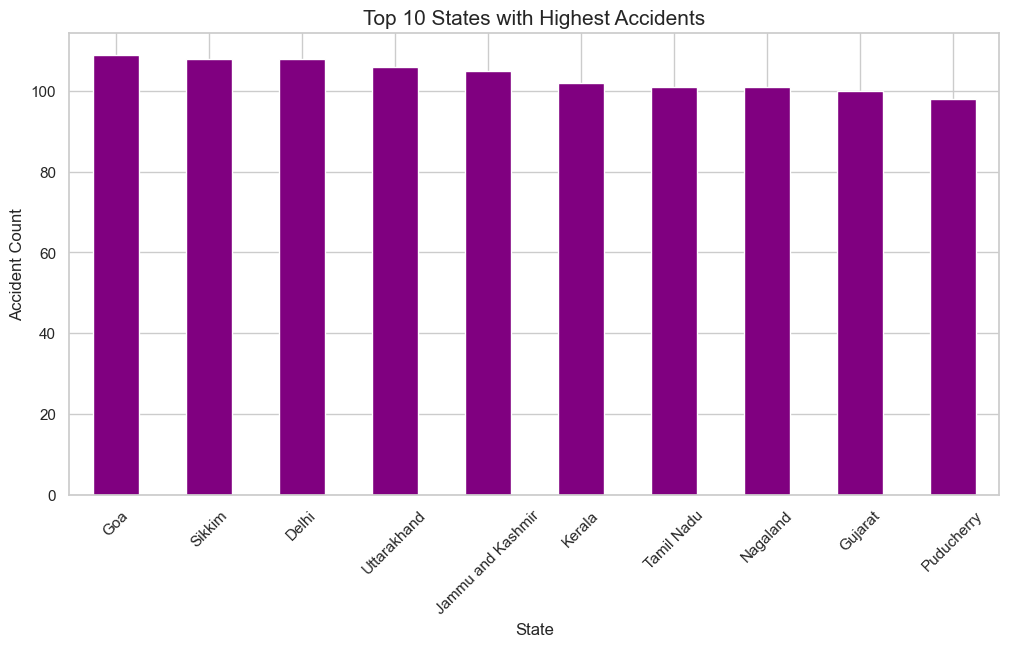

In [23]:
plt.figure(figsize=(12,6))
df['State Name'].value_counts().head(10).plot(kind='bar', color='purple')

plt.title("Top 10 States with Highest Accidents", fontsize=15)
plt.xlabel("State")
plt.ylabel("Accident Count")
plt.xticks(rotation=45)

plt.show()

# PIE CHART (Accident Severity Distribution)

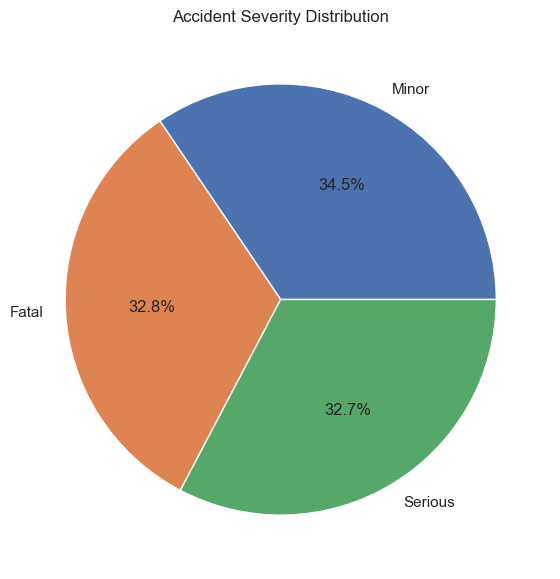

In [24]:
df['Accident Severity'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Accident Severity Distribution")
plt.ylabel("")
plt.show()

# HISTOGRAM (Driver Age Distribution)

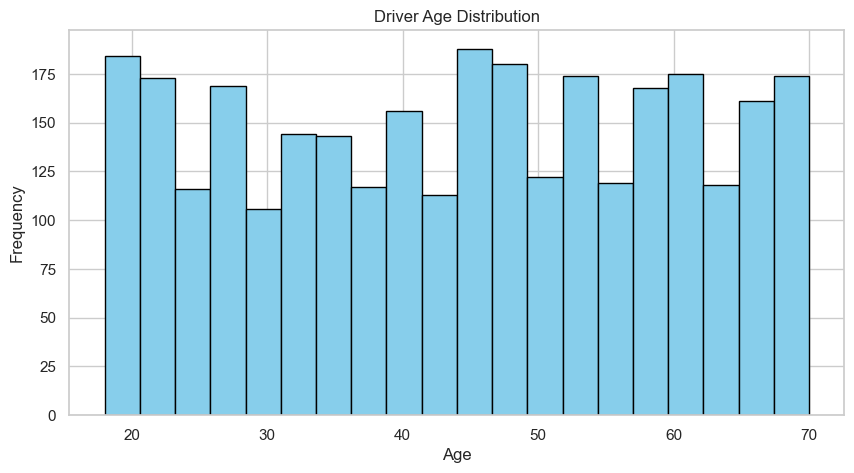

In [25]:
plt.figure(figsize=(10,5))

plt.hist(df['Driver Age'], bins=20, color='skyblue', edgecolor='black')

plt.title("Driver Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# SCATTER PLOT (Speed Limit vs Casualties)

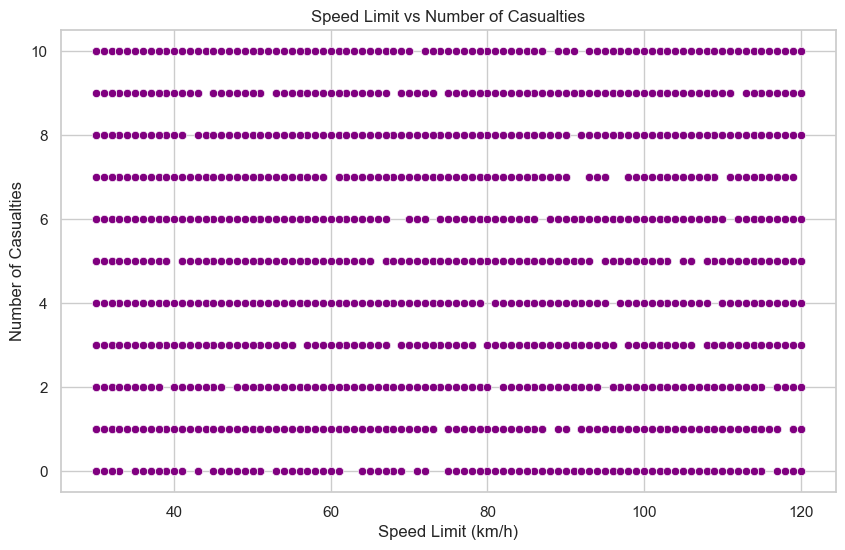

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Speed Limit (km/h)',
    y='Number of Casualties',
    data=df,
    color='purple'
)

plt.title("Speed Limit vs Number of Casualties")
plt.show()

# LINE PLOT (Accidents by Year)

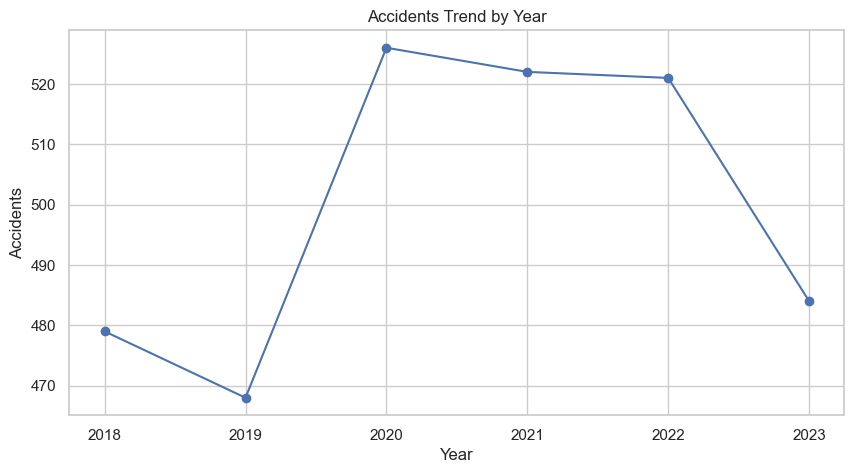

In [27]:
plt.figure(figsize=(10,5))

df['Year'].value_counts().sort_index().plot(kind='line', marker='o')

plt.title("Accidents Trend by Year")
plt.xlabel("Year")
plt.ylabel("Accidents")

plt.show()

# Count Plot (Weather Conditions)

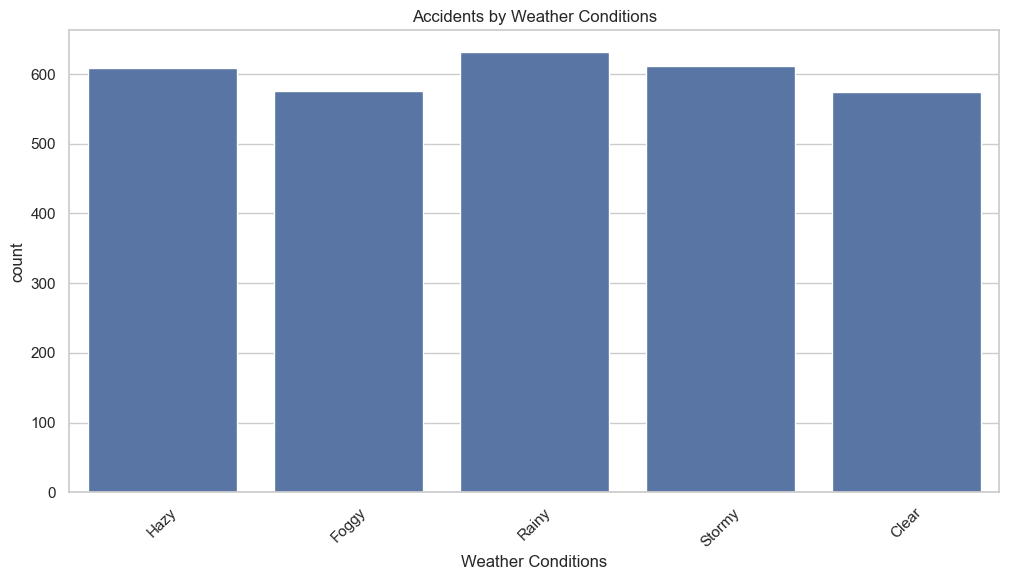

In [28]:
plt.figure(figsize=(12,6))

sns.countplot(x='Weather Conditions', data=df)

plt.title("Accidents by Weather Conditions")
plt.xticks(rotation=45)

plt.show()

# Box Plot (Severity vs Driver Age)

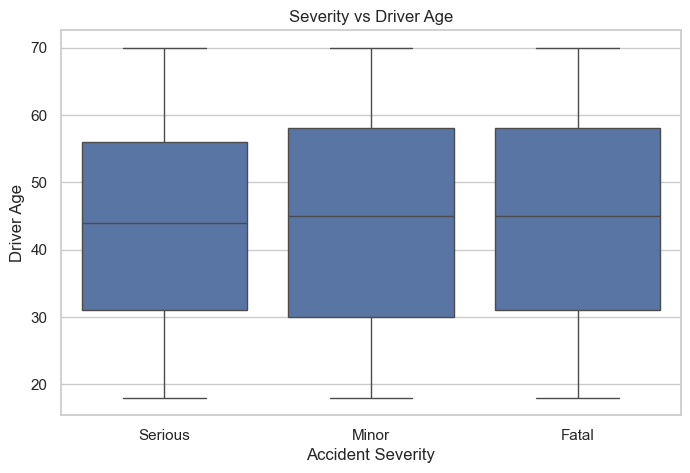

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Accident Severity', y='Driver Age', data=df)

plt.title("Severity vs Driver Age")

plt.show()

# Monthly Accident Trend

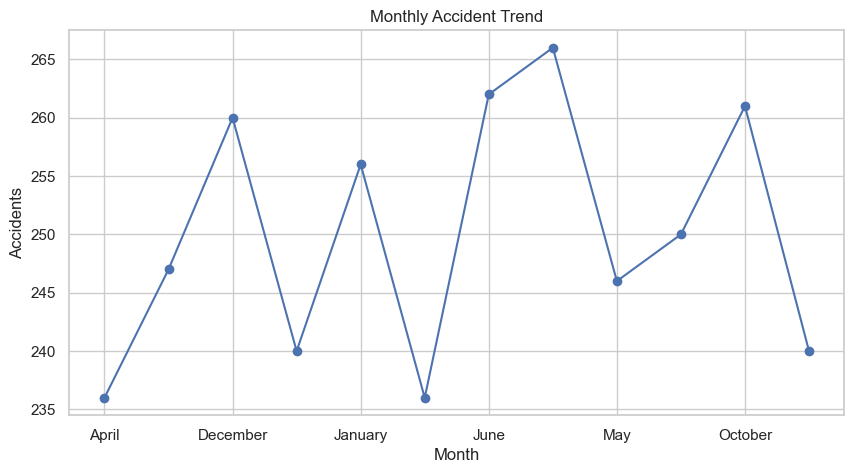

In [30]:
plt.figure(figsize=(10,5))
df['Month'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Monthly Accident Trend")
plt.xlabel("Month")
plt.ylabel("Accidents")
plt.show()

# Day of Week Analysis

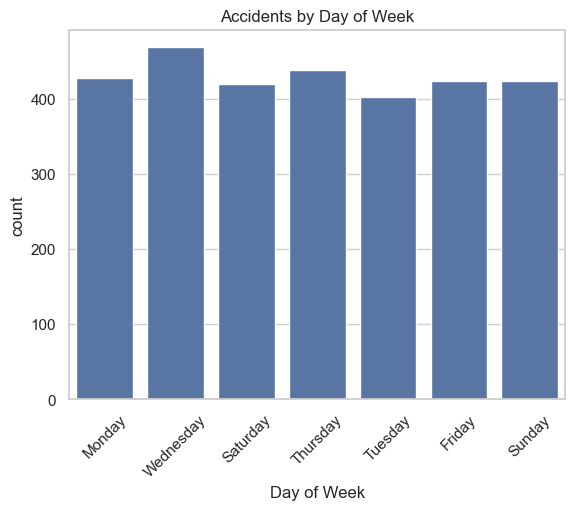

In [31]:
sns.countplot(x='Day of Week', data=df)
plt.title("Accidents by Day of Week")
plt.xticks(rotation=45)
plt.show()

# Gender Analysis

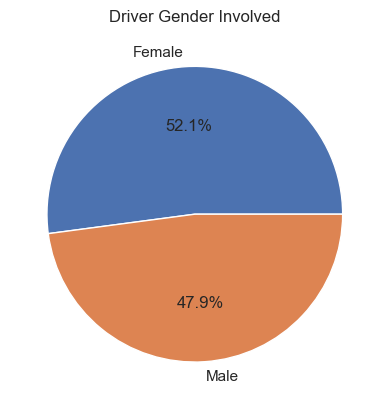

In [32]:
df['Driver Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Driver Gender Involved")
plt.ylabel("")
plt.show()

# Vehicle Type vs Severity

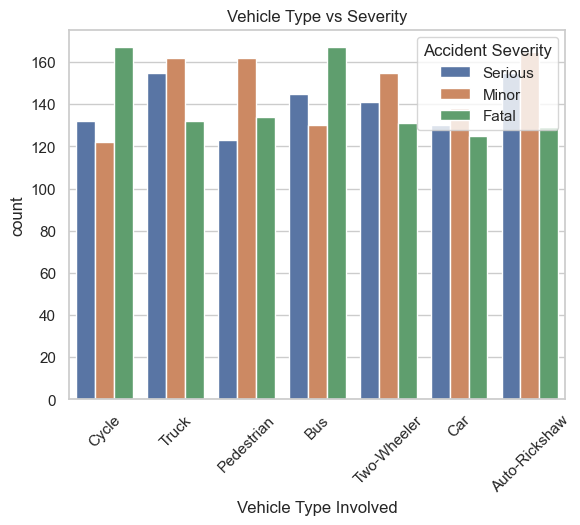

In [33]:
sns.countplot(x='Vehicle Type Involved', hue='Accident Severity', data=df)
plt.xticks(rotation=45)
plt.title("Vehicle Type vs Severity")
plt.show()

# Average Casualties by Month

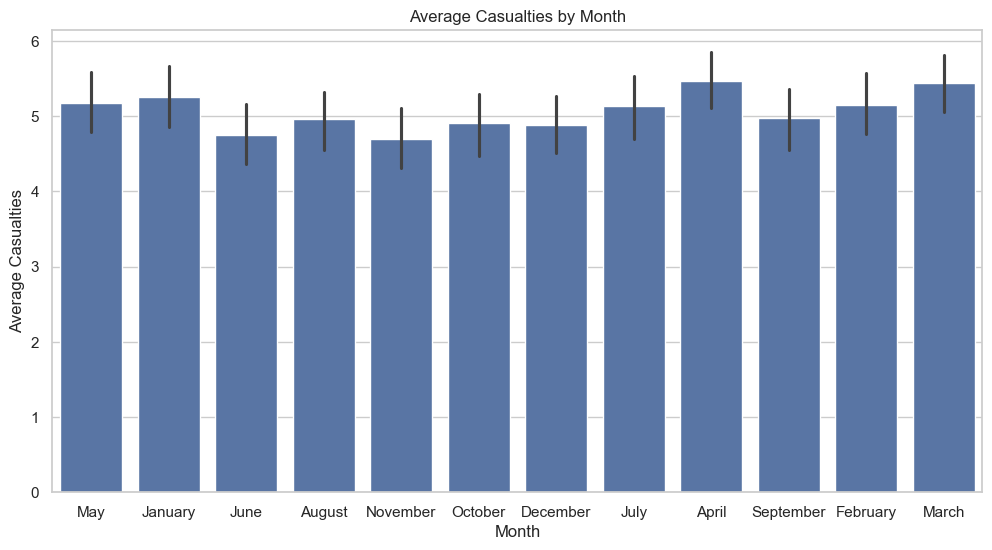

In [34]:
plt.figure(figsize=(12,6))
sns.barplot(x='Month', y='Number of Casualties', data=df)
plt.title("Average Casualties by Month")
plt.xlabel("Month")
plt.ylabel("Average Casualties")
plt.show()

# Top 10 states with casualties

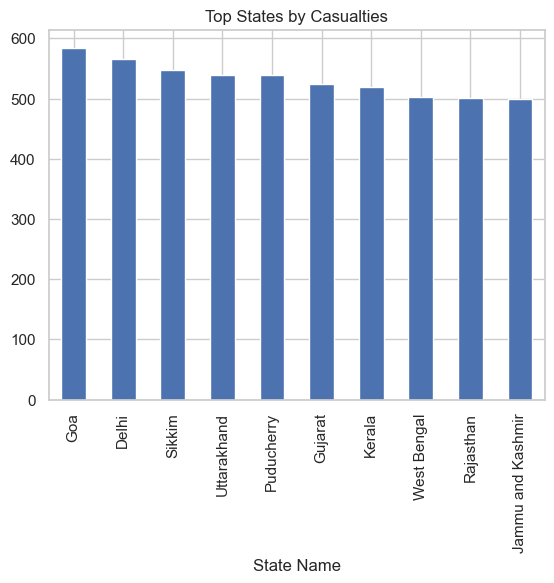

In [35]:
df.groupby('State Name')['Number of Casualties'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top States by Casualties")
plt.show()

 # KDE Plot: Driver Age Distribution

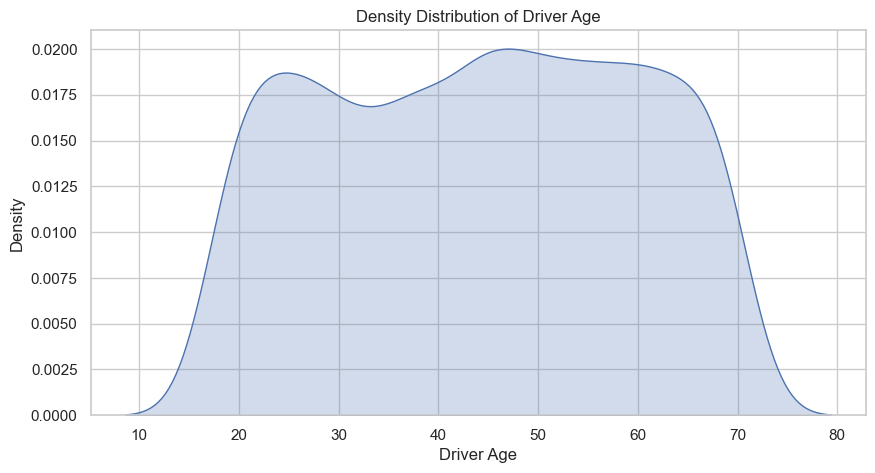

In [36]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['Driver Age'], fill=True)
plt.title("Density Distribution of Driver Age")
plt.xlabel("Driver Age")
plt.show()

# KDE Plot: Speed Limit Distribution

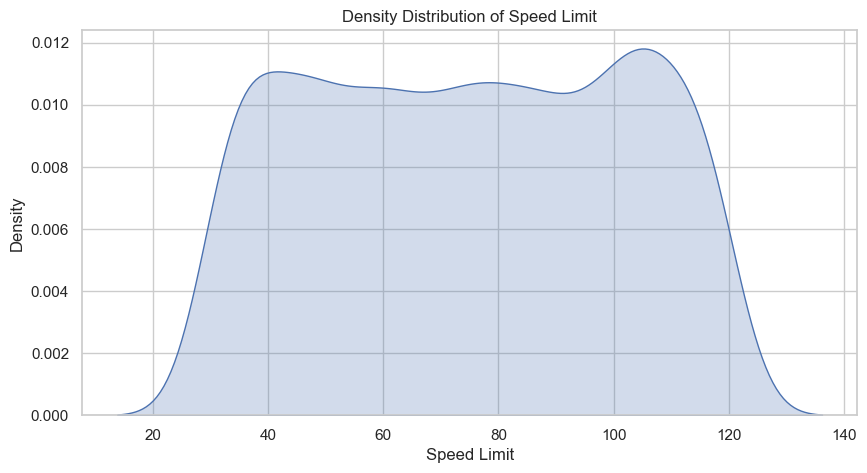

In [37]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['Speed Limit (km/h)'], fill=True)
plt.title("Density Distribution of Speed Limit")
plt.xlabel("Speed Limit")
plt.show()

# Casualties Distribution

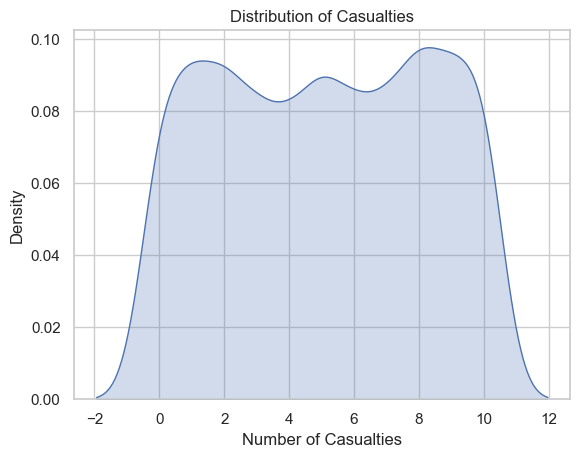

In [38]:
sns.kdeplot(df['Number of Casualties'], fill=True)
plt.title("Distribution of Casualties")
plt.show()

# Compare by Severity

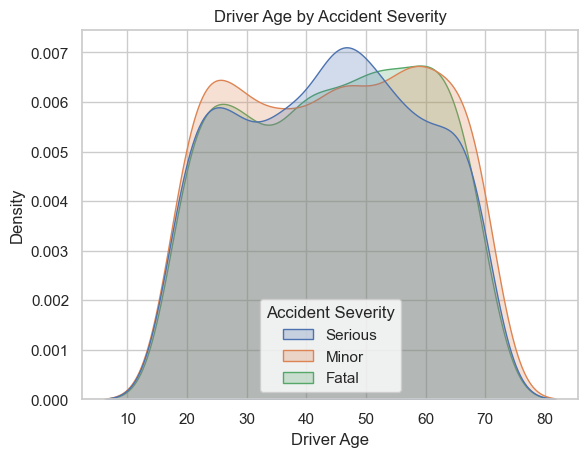

In [39]:
sns.kdeplot(data=df, x='Driver Age', hue='Accident Severity', fill=True)
plt.title("Driver Age by Accident Severity")
plt.show()

# Pair Plot: Important Numerical Features

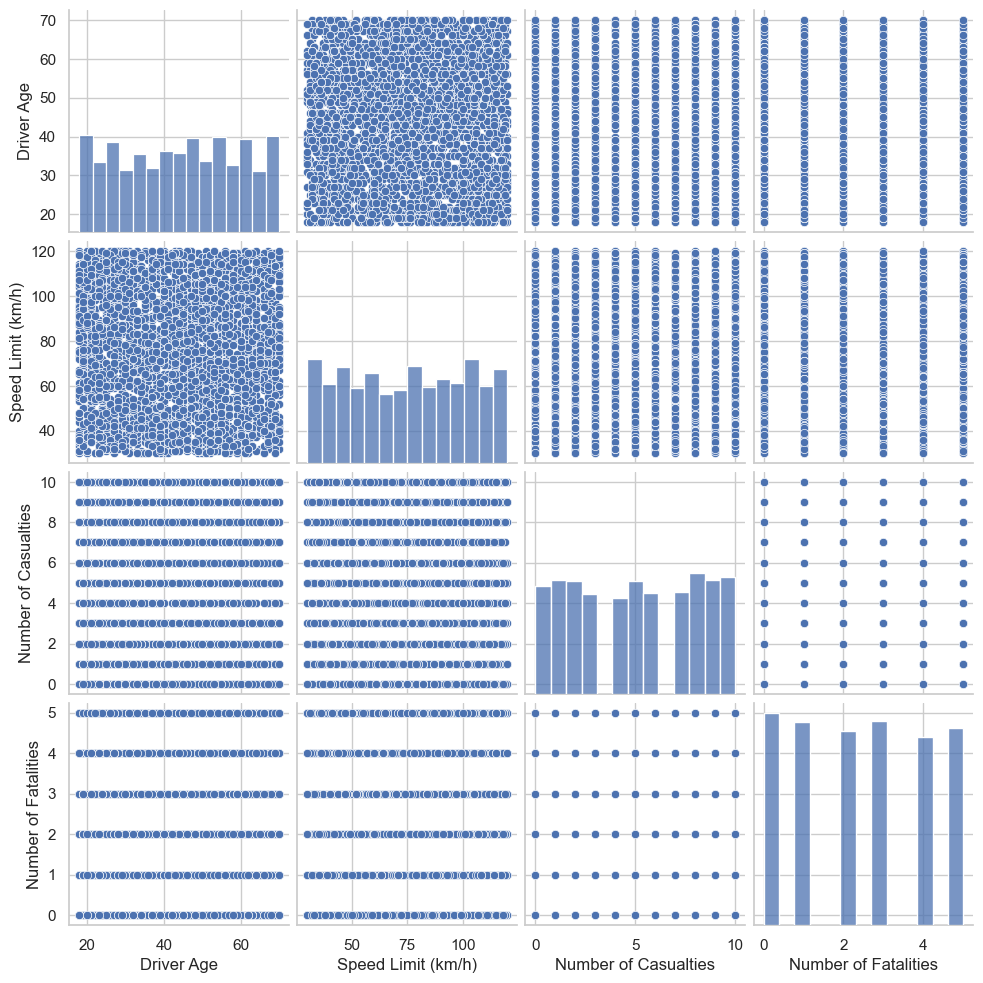

In [40]:
sns.pairplot(df[['Driver Age',
                 'Speed Limit (km/h)',
                 'Number of Casualties',
                 'Number of Fatalities']])
plt.show()

# With Severity Color

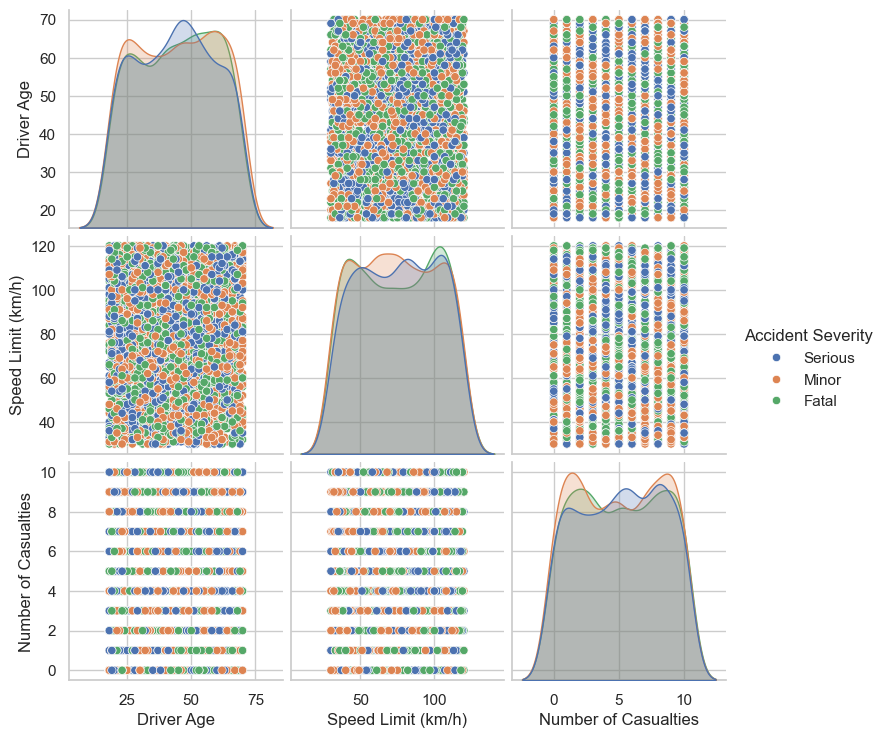

In [41]:
sns.pairplot(
    df[['Driver Age',
        'Speed Limit (km/h)',
        'Number of Casualties',
        'Accident Severity']],
    hue='Accident Severity'
)
plt.show()

# Insights

# Detailed Insight Generation

## Project Title: Road Accident Analysis and Prediction using Indian Accident Dataset

# 1. State-wise Accident Analysis

## Insight:

The bar plot of accidents by state shows that a few states contribute a significantly larger share of total accidents compared to others.

### Interpretation:

This may be due to:

- High population density
- Large number of registered vehicles
- Urban traffic congestion
- Better accident reporting systems
- Presence of highways and industrial routes

### Business Question Answered:

Which states need priority road safety measures?

### Recommendation:

Government authorities should allocate more traffic monitoring resources and safety campaigns in high-risk states.

---

# 2. Accident Severity Distribution

## Insight:

The pie chart indicates that most accidents belong to minor and moderate severity categories, while severe accidents occur less frequently but have major consequences.

### Interpretation:

- Minor accidents are common in city traffic.
- Severe accidents may be linked with highways, overspeeding, poor weather, or late-night driving.

### Business Question Answered:

What type of accidents occur most frequently?

### Recommendation:

Daily traffic control can reduce minor accidents, while highway safety systems can reduce severe accidents.

---

# 3. Driver Age Analysis

## Insight:

Histogram and KDE plots show that the majority of accidents involve drivers in the age group of approximately 20 to 40 years.

### Interpretation:

This age group is highly active on roads due to:

- Office commuting
- Frequent travel
- Higher vehicle ownership
- Risk-taking behavior in some drivers

Older age groups show lower accident involvement due to lower travel frequency.

### Business Question Answered:

Which driver age group is most involved in accidents?

### Recommendation:

Road safety awareness campaigns should target young and middle-aged drivers.

---

# 4. Speed Limit and Casualties Relationship

## Insight:

Scatter plot shows that accidents occurring on roads with higher speed limits tend to result in more casualties.

### Interpretation:

At higher speed:

- Driver reaction time decreases
- Collision force increases
- Fatality risk increases

### Business Question Answered:

Does speed impact accident severity?

### Recommendation:

Install speed cameras, enforce speed laws, and add warning systems on high-speed roads.

---

# 5. Year-wise Accident Trend

## Insight:

Line chart of accidents by year shows fluctuations across years.

### Interpretation:

Possible reasons:

- Growth in vehicles over time
- Infrastructure development
- Traffic rule enforcement changes
- Improved emergency response systems
- Pandemic or lockdown effects in certain years

### Business Question Answered:

Are accidents increasing or decreasing over time?

### Recommendation:

Authorities should compare yearly trends to measure policy effectiveness.

---

# 6. Weather Conditions Impact

## Insight:

Count plot shows increased accidents under adverse weather such as rain, fog, and cloudy conditions.

### Interpretation:

Poor weather causes:

- Reduced visibility
- Slippery roads
- Longer braking distance
- Driver stress

### Business Question Answered:

How does weather affect accidents?

### Recommendation:

Issue weather alerts, improve drainage, use reflective road markings, and increase patroling during poor weather.

---

# 7. Road Type Analysis

## Insight:

Accidents are concentrated on certain road types such as highways, urban roads, and intersections.

### Interpretation:

- Highways involve higher speed collisions
- Intersections involve turning conflicts
- Urban roads involve congestion-based crashes

### Business Question Answered:

Which road types are most risky?

### Recommendation:

Improve signals, lane management, divider systems, and surveillance at risky road types.

---

# 8. Lighting Conditions Analysis

## Insight:

Accidents occurring during night or low-light conditions are associated with higher severity.

### Interpretation:

Poor lighting reduces visibility of:

- Pedestrians
- Road signs
- Obstacles
- Turning vehicles

### Business Question Answered:

Does lighting condition affect accidents?

### Recommendation:

Install LED street lights, reflective signs, and smart lighting systems.

---

# 9. Gender-based Analysis

## Insight:

If male drivers dominate accident involvement, it may indicate higher driving exposure and more road presence.

### Interpretation:

This may reflect:

- Larger share of male drivers
- Commercial driving participation
- Higher long-distance travel frequency

### Recommendation:

Awareness campaigns should target all driver groups with special focus on high-exposure categories.

---

# 10. Vehicle Type Analysis

## Insight:

Certain vehicle categories such as bikes, cars, trucks, or buses may show higher accident involvement.

### Interpretation:

- Bikes are vulnerable due to less protection
- Trucks create high-impact collisions
- Cars dominate due to high ownership

### Business Question Answered:

Which vehicle type needs stricter regulation?

### Recommendation:

Helmet checks, truck lane discipline, commercial vehicle training, seatbelt enforcement.

---

# 11. Fatalities vs Casualties

## Insight:

Some accidents produce many injuries but low fatalities, while high-speed crashes may produce higher fatalities.

### Interpretation:

This shows emergency medical access and crash intensity both matter.

### Recommendation:

Improve ambulance response time and trauma care near highways.

---

# 12. Overall Final Business Insight

Road accidents are not caused by one factor alone. They are influenced by:

- Human behavior
- Speed
- Weather
- Road design
- Vehicle type
- Time of day
- Enforcement quality

### Final Recommendation:

A data-driven road safety strategy using predictive analytics can significantly reduce accidents and save lives.